# Motivation for Modeling Violations


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config as c
from violmulti.data.dataset_loader import DatasetLoader
from pandas.api.types import CategoricalDtype

%load_ext autoreload
%autoreload 2
sns.set_context("talk")

In [3]:
df = DatasetLoader().load_data() # this loads the trained data

DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


In [4]:
df

,animal_id,session_date,session_file_counter,rig_id,training_stage,s_a,s_b,hit,violation,trial_not_started,...,r_water_vol,antibias_beta,antibias_right_prob,using_psychometric_pairs,choice,session,session_relative_to_old,n_prev_trial_not_started,trial,animal_id_session
0,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000000,3,0.500000,NaN,2,326,326.0,0.0,1,W051_s326
1,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000001,3,0.500000,NaN,2,326,326.0,0.0,2,W051_s326
2,W051,2014-07-17,327,19,4,76.0,68.0,NaN,1,False,...,18.000004,3,0.500000,NaN,2,326,326.0,0.0,3,W051_s326
3,W051,2014-07-17,327,19,4,68.0,76.0,1.0,0,False,...,18.000014,3,0.500000,NaN,0,326,326.0,0.0,4,W051_s326
4,W051,2014-07-17,327,19,4,84.0,76.0,1.0,0,False,...,18.000033,3,0.500000,NaN,1,326,326.0,0.0,5,W051_s326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144770,W094,2016-09-01,526,5,4,60.0,68.0,NaN,1,False,...,37.334785,3,0.471529,0.0,2,526,463.0,0.0,1490,W094_s526
2144771,W094,2016-09-01,526,5,4,60.0,68.0,NaN,1,False,...,37.335700,3,0.471529,0.0,2,526,463.0,0.0,1491,W094_s526
2144772,W094,2016-09-01,526,5,4,84.0,92.0,1.0,0,False,...,37.336613,3,0.471529,0.0,0,526,463.0,0.0,1492,W094_s526
2144773,W094,2016-09-01,526,5,4,68.0,76.0,0.0,0,False,...,37.337525,3,0.476910,0.0,1,526,463.0,0.0,1493,W094_s526


In [7]:
print("Number of sessions:", df.groupby("animal_id").session.nunique().sum())
print("Number of animals:", df['animal_id'].nunique())
print("Number of trials:", len(df))


Number of sessions: 5251
Number of animals: 16
Number of trials: 1867005


In [19]:
print("Number of Violation trials:", len(df.query("violation == 1")))
print("Percent of Violations:", (len(df.query("violation == 1")) / len(df)) * 100)

Number of Violation trials: 324443
Percent of Violations: 17.37772528729168


In [44]:
# Reorder the 'Choice' column to be Left, Violation, Right
CHOICE_ORDER = ["Left", "Violation", "Right"]
CHOICE_PAL = [c.LEFT_COLOR, c.VIOLATION_COLOR, c.RIGHT_COLOR]

## Single Session Example


In [86]:
ex_animal = 'W075'
ex_session = 408

ex_df = df.query("animal_id == @ex_animal and session == @ex_session").copy()


ex_df["Choice"] = ex_df["choice"].map({0: "Left", 1: "Right", 2: "Violation"})
cat_type = CategoricalDtype(
    categories=CHOICE_ORDER,
    ordered=True
)
ex_df['Choice'] = ex_df['Choice'].astype(cat_type)

ex_df.agg(
    hit_rate = ("hit", "mean"),
    violation_rate = ("violation", "mean"),
    n_trials = ("trial", "count")
)


,hit,violation,trial
hit_rate,0.878378,NaN,NaN
violation_rate,NaN,0.119048,NaN
n_trials,NaN,NaN,420.0


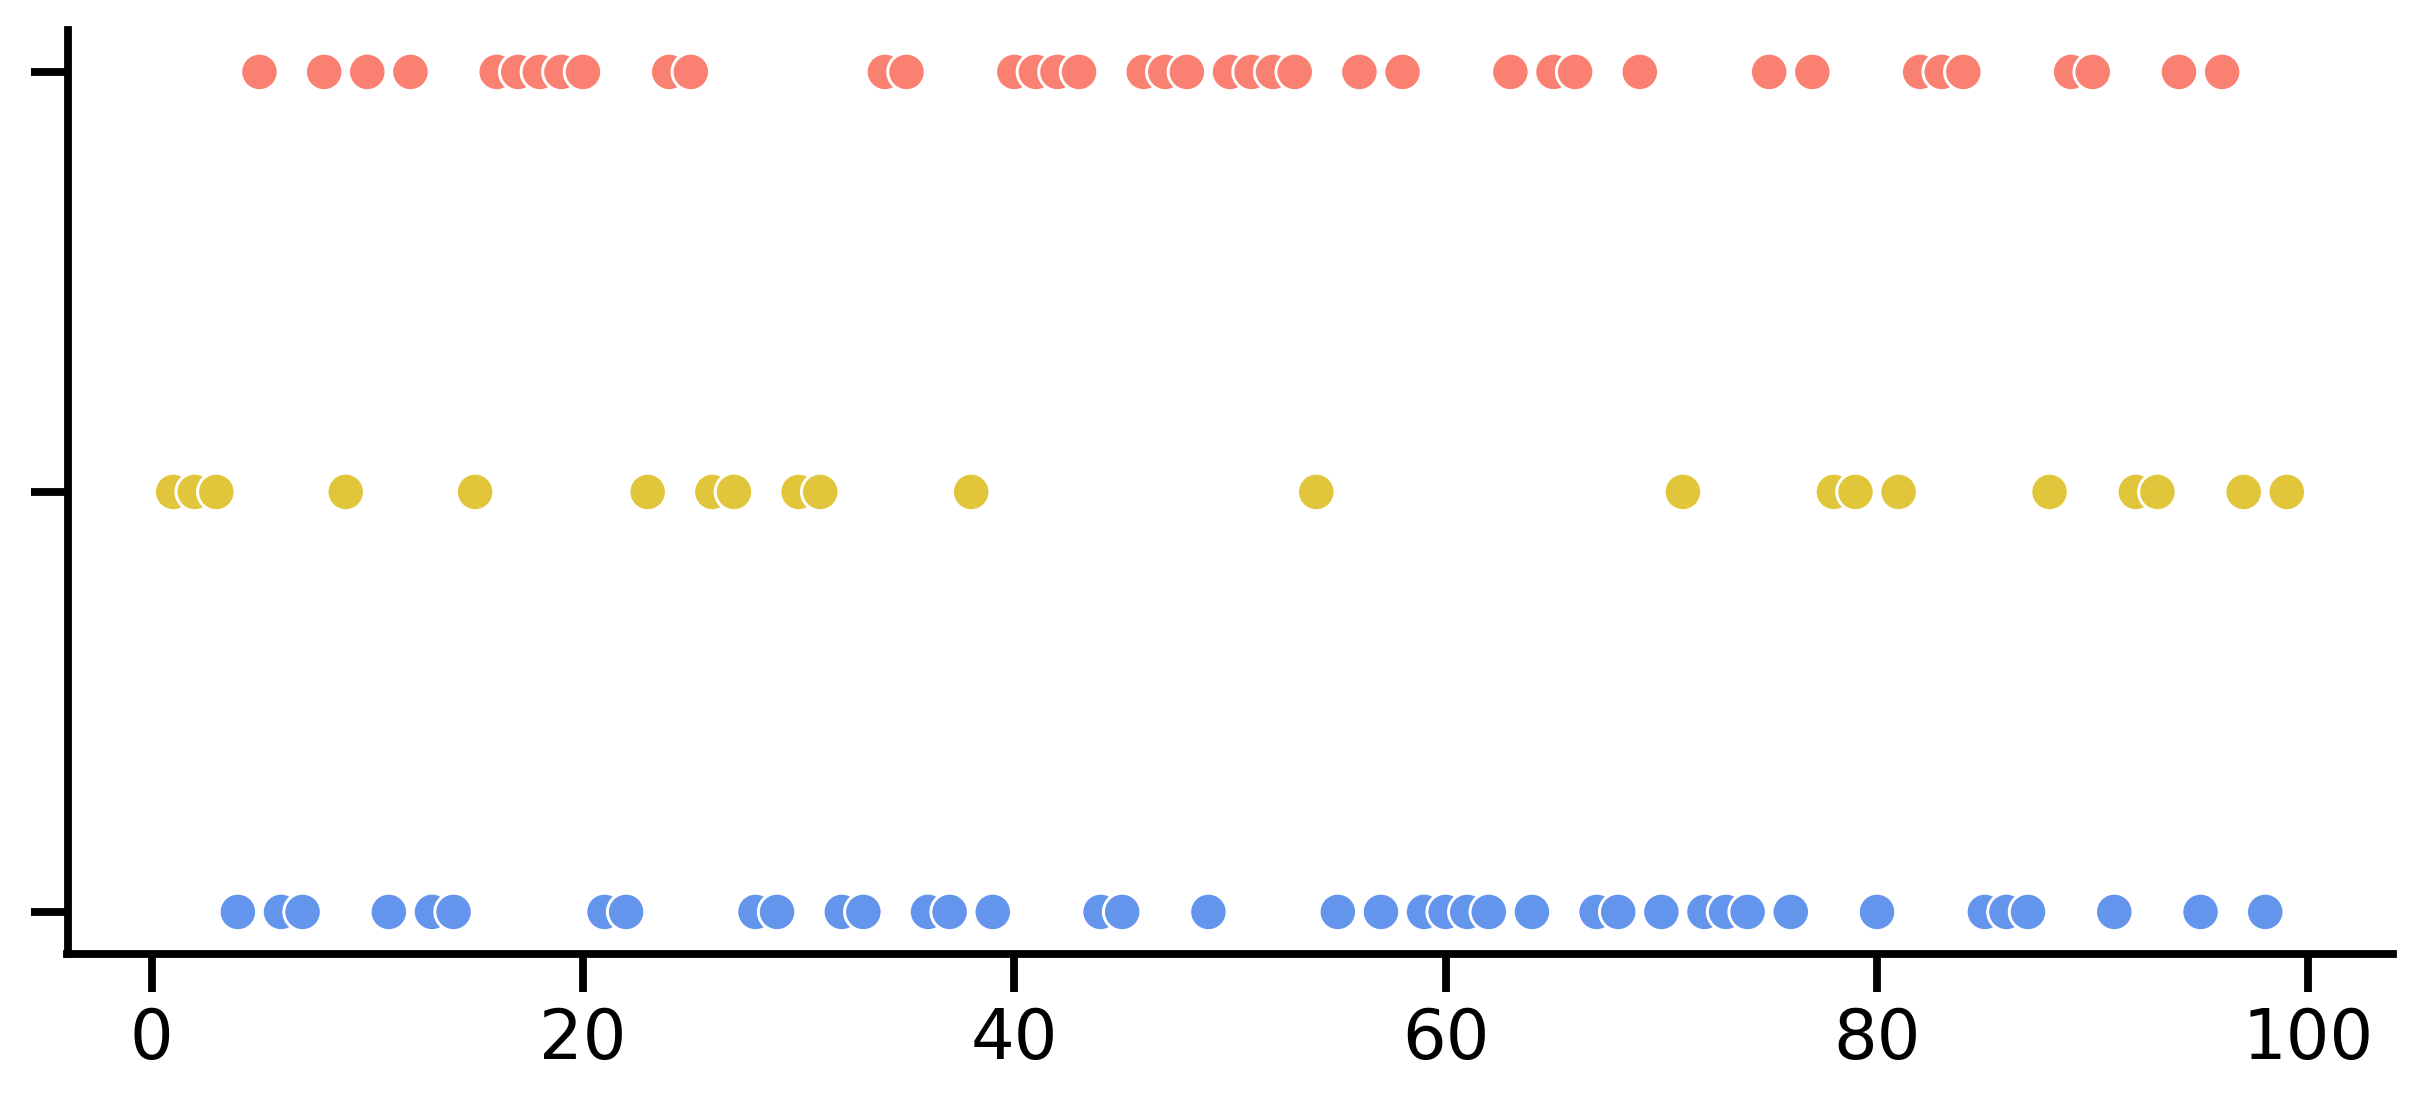

In [118]:

fig, ax = plt.subplots(figsize=(10,4), dpi=300)

sns.despine()
sns.scatterplot(
    x="trial",
    y="Choice",
    data=ex_df.query("trial < 100"),
    hue="Choice",
    hue_order=CHOICE_ORDER,
    palette=CHOICE_PAL
)

ax.set(xlabel="", ylabel="")
ax.set_yticklabels([])
ax.legend().remove()

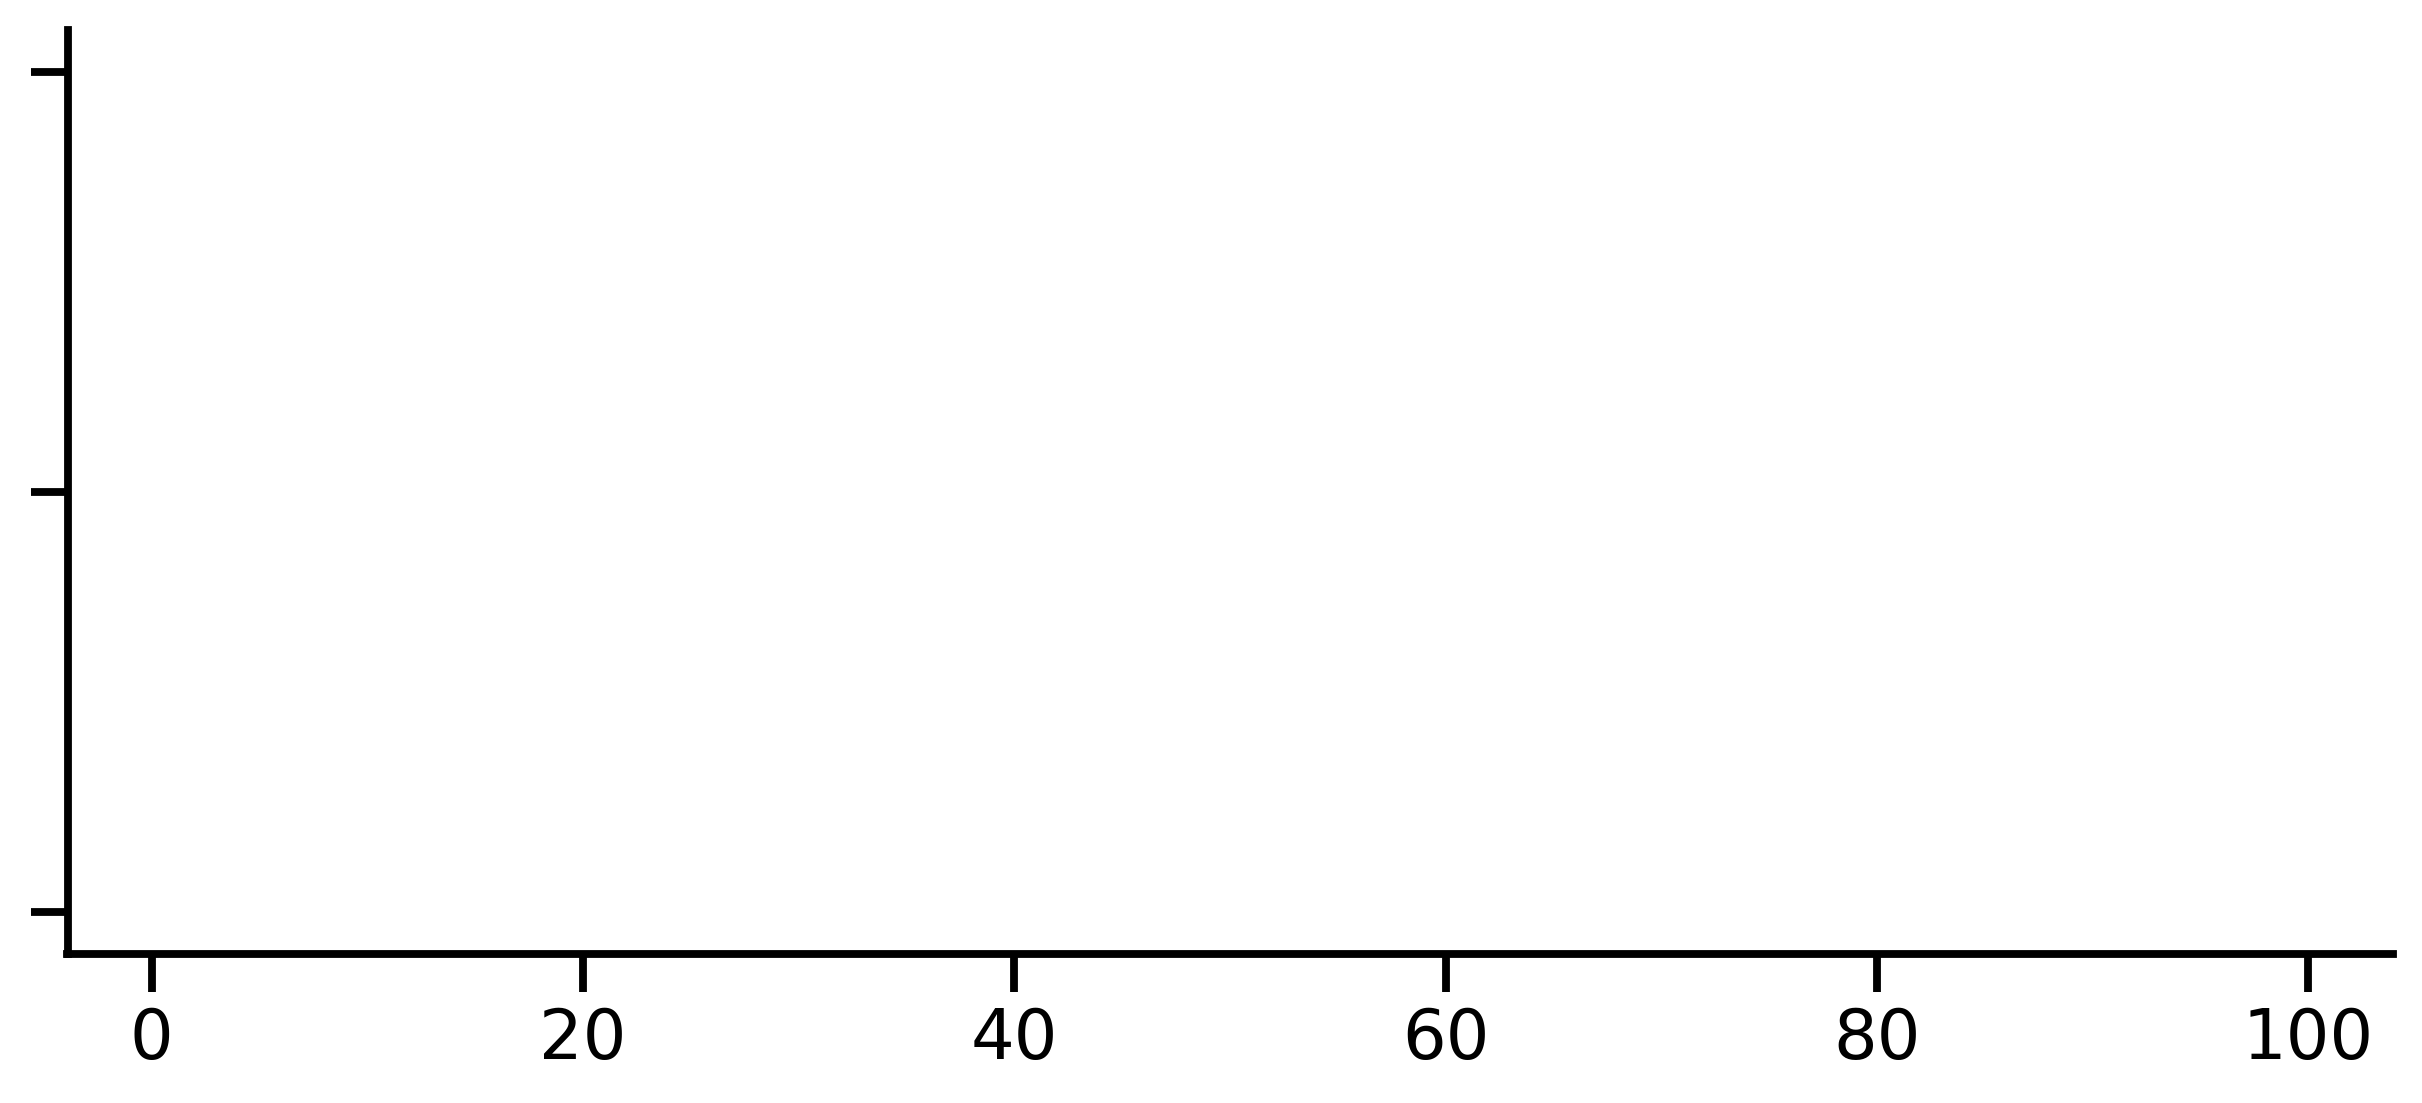

In [161]:

fig, ax = plt.subplots(figsize=(10,4), dpi=300)

sns.despine()
sns.scatterplot(
    x="trial",
    y="Choice",
    data=ex_df.query("trial < 100"),
    hue="Choice",
    hue_order=CHOICE_ORDER,
    palette=["white", "white", "white"]
)

ax.set(xlabel="", ylabel="")
ax.set_yticklabels([])
ax.legend().remove()

## Choice Distributions- All Sessions


In [119]:
choice_dist_df = pd.read_csv("data/fig1_choice_dist_df.csv")
choice_dist_df.head()

,animal_id,session,choice,proportion,Choice,percentage
0,W051,326,1,0.458689,Right,45.87
1,W051,326,0,0.444444,Left,44.44
2,W051,326,2,0.096866,Violation,9.69
3,W051,327,1,0.458874,Right,45.89
4,W051,327,0,0.437229,Left,43.72


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_76731/3023127697.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, width=0.5, fill=False, zorder=10, errorbar="se", color="k", alpha =0.75, order=CHOICE_ORDER, hue_order=CHOICE_ORDER, palette=CHOICE_PAL)


[Text(0, 0, ''), Text(1, 0, ''), Text(2, 0, '')]

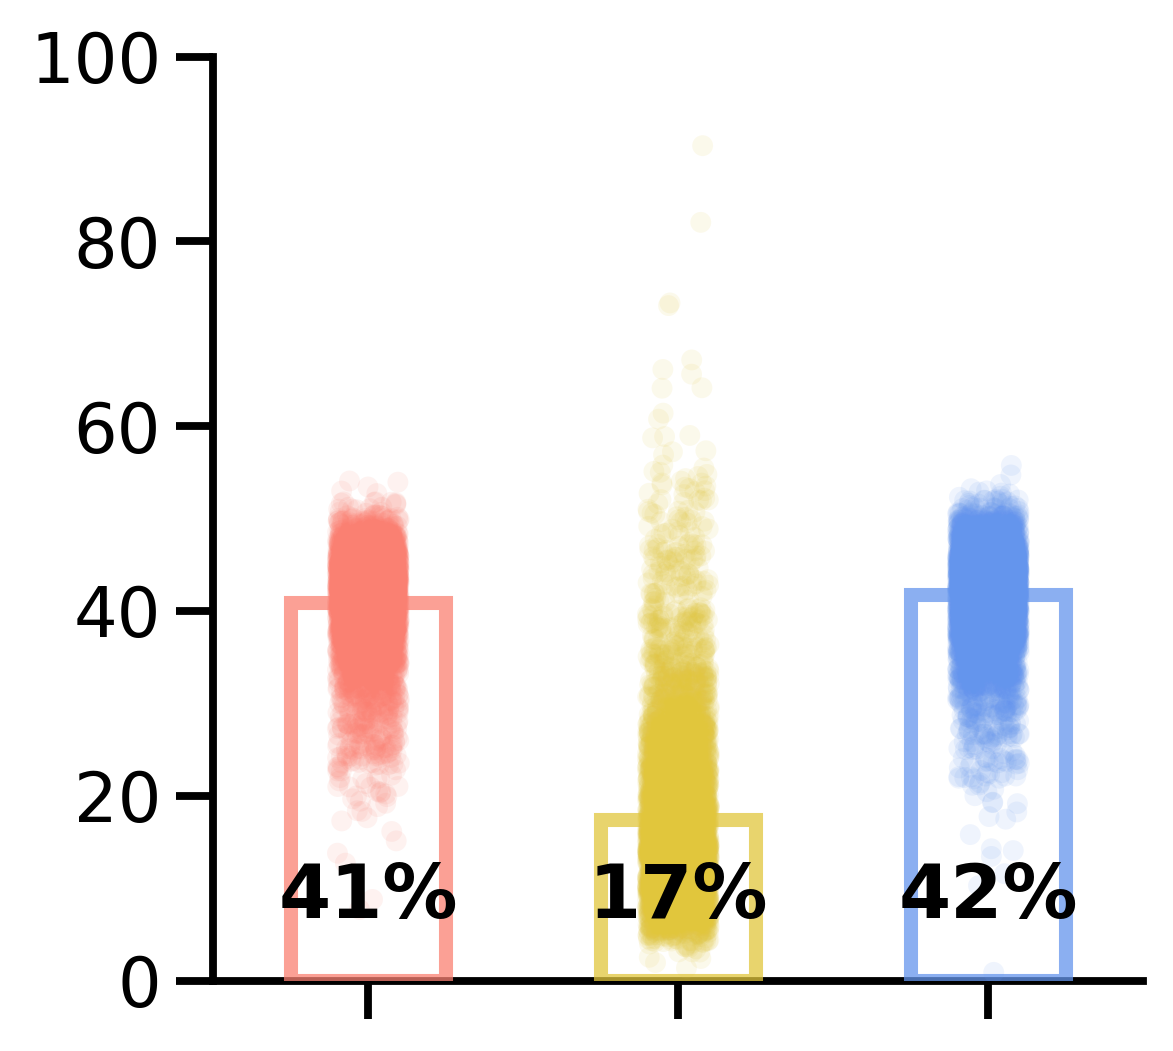

In [158]:

fig, ax = plt.subplots(figsize=(4,4), dpi=300)
sns.despine()

sns.barplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, width=0.5, fill=False, zorder=10, errorbar="se", color="k", alpha =0.75, order=CHOICE_ORDER, hue_order=CHOICE_ORDER, palette=CHOICE_PAL)
sns.stripplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, alpha=0.10, palette=CHOICE_PAL, hue="Choice", order=CHOICE_ORDER, hue_order=CHOICE_ORDER)
ax.set(xlabel="", ylabel="", ylim=(0, 100))

# Add text labels for each Choice group at y=5
for choice in choice_dist_df["Choice"].unique():
    percentage = choice_dist_df[choice_dist_df["Choice"] == choice]["percentage"].mean()
    ax.text(x=choice, y=5, s=f"{percentage:.0f}%", ha='center', va='bottom', fontweight='bold', zorder=10)

# remove y tick labels
ax.set_xticklabels([])




## Hit Rate by Violation Rate


In [124]:
perf_agg_df = pd.read_csv("data/fig1_animal_agg_perf_df.csv") 


In [125]:
# Fit a simple linear regression model
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = perf_agg_df[['hit_rate']]
y = perf_agg_df['viol_rate']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)
print(f"Slope: {model.coef_[0]}, Intercept: {model.intercept_}")

R-squared on aggregated data: 0.18980415688862073
Slope: -0.6442377553421731, Intercept: 69.7130625690381


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


[(0.0, 35.0), (70.0, 96.0)]

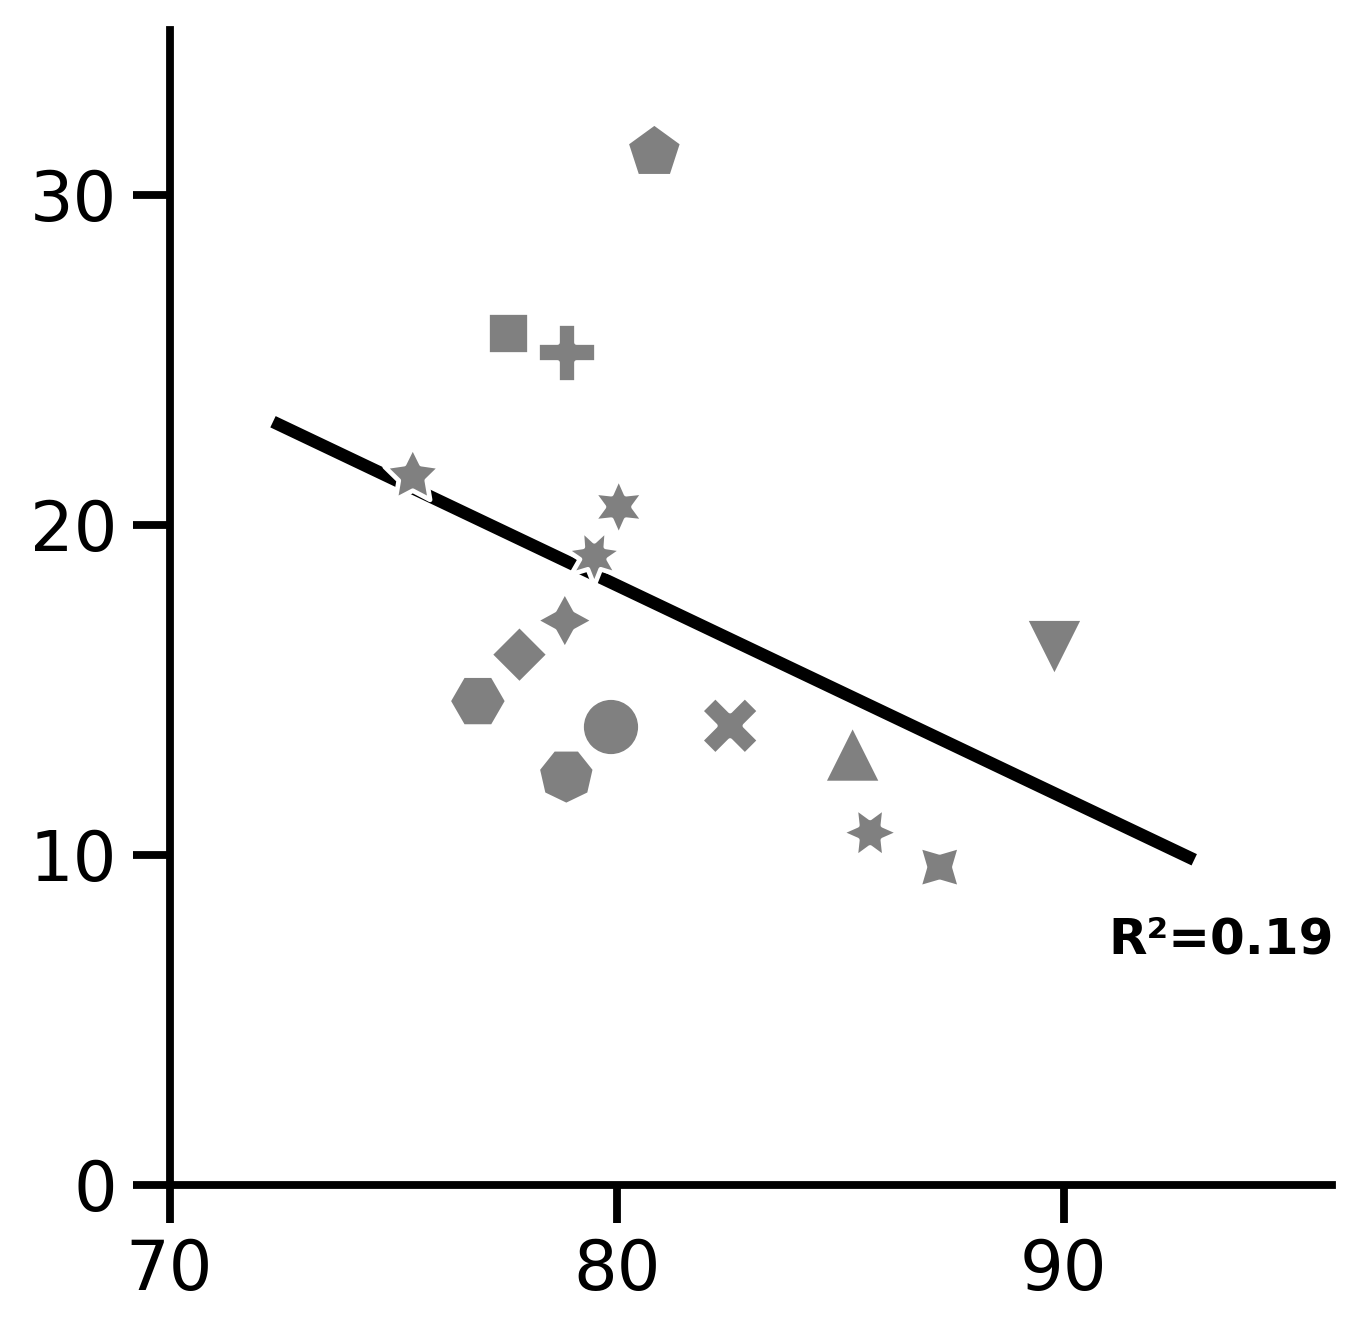

In [159]:
fig, ax = plt.subplots(figsize=(5,5), dpi=300)
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit_rate", y="viol_rate", data=perf_agg_df, ax=ax, style="animal_id", alpha=1, s=200, color="gray")
ax.set(xlabel="", ylabel="")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(perf_agg_df['hit_rate'].min() - 3, perf_agg_df['hit_rate'].max() + 3, 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='k', linewidth=3, label=f"(R²={r2_aggregated:.2f})", zorder=0)
ax.legend().remove()

ax.text(x=91, y=7, s=f"R²={r2_aggregated:.2f}", fontsize=12, fontweight='bold')

# Set x-ticks to be every 10
ax.set_xticks(np.arange(70, 97, 10))
ax.set_yticks(np.arange(0, 40, 10))

ax.set(ylim=(0, 35), xlim=(70, 96))